In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [18]:
data = {
    'Bedrooms': [2, 3, 3, 4, 4, 5, 2, 3, 4, 5,
                 3, 4, 2, 5, 4, 3, 4, 5, 2, 3],

    'Bathrooms': [1, 2, 2, 3, 3, 4, 1, 2, 3, 4,
                  2, 3, 1, 4, 3, 2, 3, 4, 1, 2],

    'LivingArea': [800, 1200, 1400, 1800, 2000, 2500,
                   900, 1300, 1900, 2400, 1500, 2100,
                   850, 2600, 2200, 1250, 1950, 2800,
                   750, 1350],

    'HouseAge': [20, 15, 10, 8, 5, 3, 25, 12, 7, 4,
                 9, 6, 30, 2, 5, 11, 8, 1, 28, 13],

    'Garage': [0, 1, 1, 1, 1, 2, 0, 1, 1, 2,
               1, 1, 0, 2, 1, 1, 1, 2, 0, 1],

    'Price': [150000, 220000, 250000, 350000, 400000,
              500000, 140000, 230000, 380000, 480000,
              280000, 420000, 130000, 520000, 450000,
              240000, 390000, 550000, 120000, 260000]
}

df = pd.DataFrame(data)

print(df.head())

   Bedrooms  Bathrooms  LivingArea  HouseAge  Garage   Price
0         2          1         800        20       0  150000
1         3          2        1200        15       1  220000
2         3          2        1400        10       1  250000
3         4          3        1800         8       1  350000
4         4          3        2000         5       1  400000


In [19]:
print(df.shape)

(20, 6)


In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Bedrooms    20 non-null     int64
 1   Bathrooms   20 non-null     int64
 2   LivingArea  20 non-null     int64
 3   HouseAge    20 non-null     int64
 4   Garage      20 non-null     int64
 5   Price       20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB
None


In [21]:
print(df.isnull().sum())

Bedrooms      0
Bathrooms     0
LivingArea    0
HouseAge      0
Garage        0
Price         0
dtype: int64


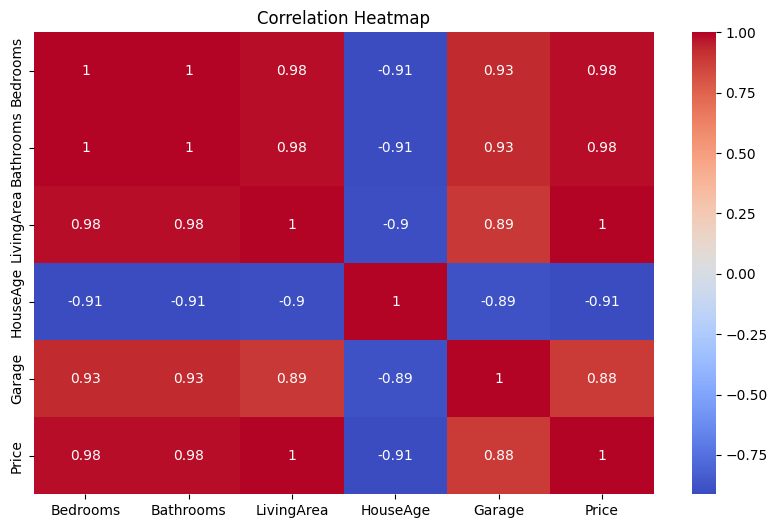

In [22]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

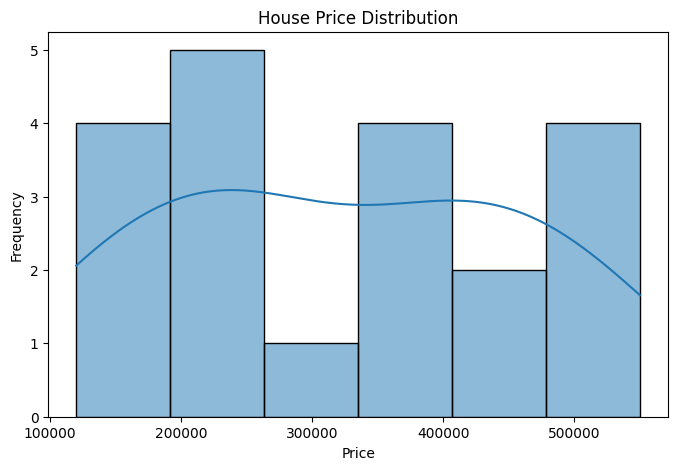

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['Price'],
    kde=True
)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

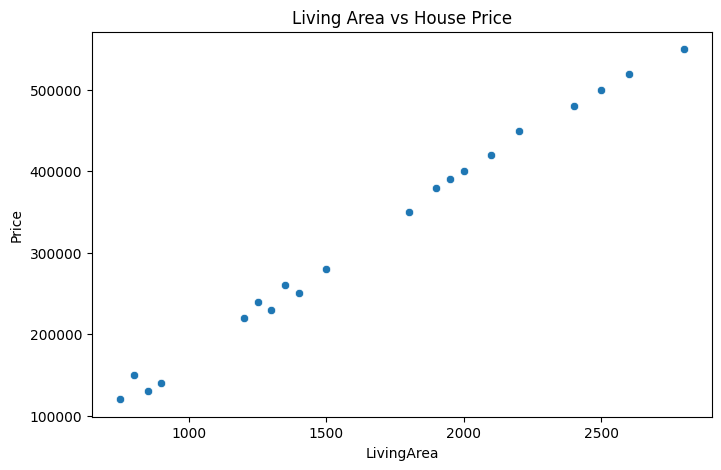

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='LivingArea',
    y='Price'
)

plt.title("Living Area vs House Price")

plt.show()

In [25]:
X = df.drop('Price', axis=1)

y = df['Price']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 5)
Testing data: (4, 5)


In [28]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

print("Mean Absolute Error:", mae_lr)

print("Mean Absolute Error:", mae_lr)

Mean Absolute Error: 15718.7022265575
Mean Absolute Error: 15718.7022265575


In [30]:
mse_lr = mean_squared_error(
    y_test,
    y_pred_lr
)

print("Mean Squared Error:", mse_lr)

Mean Squared Error: 263393588.7052974


In [31]:
rmse_lr = np.sqrt(mse_lr)

print("Root Mean Squared Error:", rmse_lr)

Root Mean Squared Error: 16229.405063196167


In [32]:
r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("R2 Score:", r2_lr)

R2 Score: 0.988862850371869


In [33]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [34]:
y_pred_rf = rf_model.predict(X_test)

In [35]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 17900.0
MSE: 486280000.0
RMSE: 22051.757299589528
R2 Score: 0.9794384778012685


In [36]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],

    'MAE': [
        mae_lr,
        mae_rf
    ],

    'MSE': [
        mse_lr,
        mse_rf
    ],

    'RMSE': [
        rmse_lr,
        rmse_rf
    ],

    'R2 Score': [
        r2_lr,
        r2_rf
    ]
})

print(results)

               Model           MAE           MSE          RMSE  R2 Score
0  Linear Regression  15718.702227  2.633936e+08  16229.405063  0.988863
1      Random Forest  17900.000000  4.862800e+08  22051.757300  0.979438


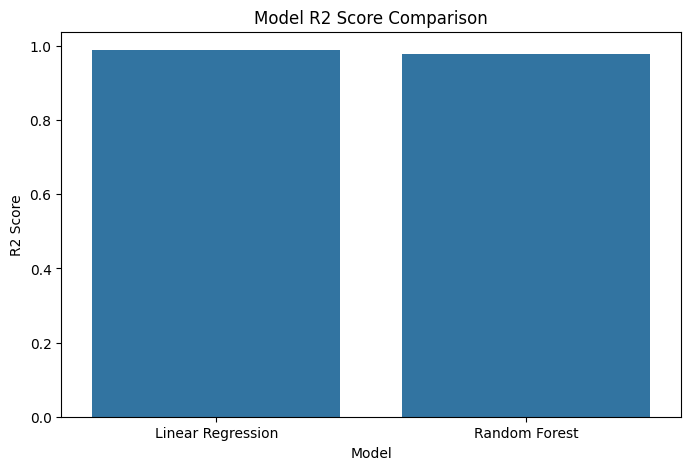

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title("Model R2 Score Comparison")

plt.show()

In [38]:
new_house = pd.DataFrame({
    'Bedrooms': [4],
    'Bathrooms': [3],
    'LivingArea': [2000],
    'HouseAge': [5],
    'Garage': [1]
})

In [39]:
predicted_price = rf_model.predict(
    new_house
)

print(
    "Predicted House Price:",
    predicted_price[0]
)

Predicted House Price: 407200.0


In [40]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred_rf
})

print(comparison)

   Actual Price  Predicted Price
0        150000         135400.0
1        550000         512600.0
2        240000         241400.0
3        220000         238200.0


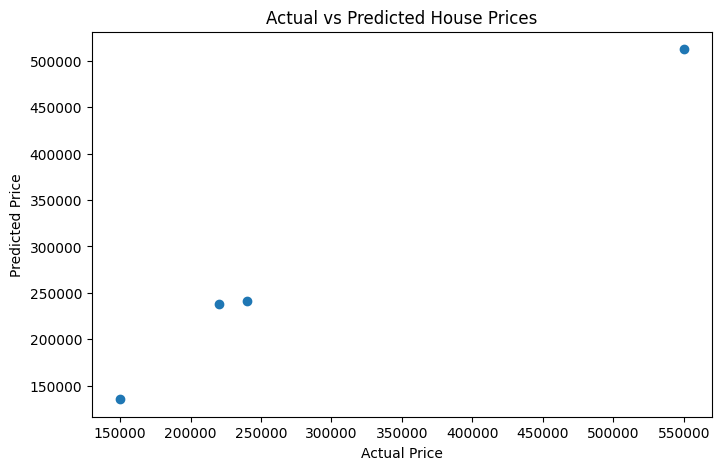

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted House Prices"
)

plt.show()